#📌 Extracción (E - Extract)

##Extracción del archivo tratado

Carga el archivo datos_limpios.csv que contiene los datos tratados anteriormente. Utiliza el mismo archivo que se limpió y organizó en el Challenge-Telecom-X-1. El archivo contiene los datos corregidos y estandarizados.

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('/content/datos_limpios.csv')

In [5]:
df

,id,Churn,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,0002-ORFBO,No,Femenino,No,Si,Si,9,Si,No,DSL,...,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Si,Si,DSL,...,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90,542.40,1.996667
2,0004-TLHLJ,Si,Masculino,No,No,No,4,Si,No,Fibra óptica,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90,280.85,2.463333
3,0011-IGKFF,Si,Masculino,Si,Si,No,13,Si,No,Fibra óptica,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00,1237.85,3.266667
4,0013-EXCHZ,Si,Femenino,Si,Si,No,3,Si,No,Fibra óptica,...,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Femenino,No,No,No,13,Si,No,DSL,...,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15,742.90,1.838333
7028,9992-RRAMN,Si,Masculino,No,Si,No,22,Si,Si,Fibra óptica,...,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10,1873.70,2.836667
7029,9992-UJOEL,No,Masculino,No,No,No,2,Si,No,DSL,...,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30,92.75,1.676667
7030,9993-LHIEB,No,Masculino,No,Si,Si,67,Si,No,DSL,...,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85,4627.65,2.261667


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   Churn                   7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   tiene_mas_60            7032 non-null   object 
 4   posee_pareja            7032 non-null   object 
 5   posee_dependientes      7032 non-null   object 
 6   tiempo_contrato         7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

In [7]:
#Ver variables categóricas y numéricas.

print(df.dtypes)

#Separar automáticamente para análisis.

categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['number']).columns.tolist()

print(f"Categóricas: {categoricas}")
print(f"Numéricas: {numericas}")

id                         object
Churn                      object
genero                     object
tiene_mas_60               object
posee_pareja               object
posee_dependientes         object
tiempo_contrato             int64
servicio_telefono          object
multiples_lineas           object
tipo_internet              object
seguridad_online           object
backup_online              object
proteccion_dispositivo     object
soporte_tecnico            object
streaming_tv               object
streaming_peliculas        object
tipo_contrato              object
factura_digital            object
metodo_pago                object
valor_mensual             float64
total_cobrado             float64
cuentas_diarias           float64
dtype: object
Categóricas: ['id', 'Churn', 'genero', 'tiene_mas_60', 'posee_pareja', 'posee_dependientes', 'servicio_telefono', 'multiples_lineas', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'stre

#🔧 Transformación (T - Transform)

🛠️ Pre-procesamiento

##Eliminación de columnas irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el id del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [8]:
#Eliminamos la columna id, porque hay 7032 registros diferentes, para cada cliente hay un registro diferente.
#Al no quitar las columnas irrelevantes puede haber overfitting.
#Puede ocurrir fuga de datos -> data lake
#Las columnas irrelevantes demoran más al ser entrenadas, crean ruido en el modelo, se utilizará mal el modelo para predecir, sesgan el modelo, pues no aportan nada, se entorpece el modelo, queda mal entrenado.

df = df.drop(columns=['id'])

In [9]:
df

,Churn,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
0,No,Femenino,No,Si,Si,9,Si,No,DSL,No,...,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60,593.30,2.186667
1,No,Masculino,No,No,No,9,Si,Si,DSL,No,...,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90,542.40,1.996667
2,Si,Masculino,No,No,No,4,Si,No,Fibra óptica,No,...,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90,280.85,2.463333
3,Si,Masculino,Si,Si,No,13,Si,No,Fibra óptica,No,...,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00,1237.85,3.266667
4,Si,Femenino,Si,Si,No,3,Si,No,Fibra óptica,No,...,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Femenino,No,No,No,13,Si,No,DSL,Si,...,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15,742.90,1.838333
7028,Si,Masculino,No,Si,No,22,Si,Si,Fibra óptica,No,...,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10,1873.70,2.836667
7029,No,Masculino,No,No,No,2,Si,No,DSL,No,...,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30,92.75,1.676667
7030,No,Masculino,No,Si,Si,67,Si,No,DSL,Si,...,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85,4627.65,2.261667


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   genero                  7032 non-null   object 
 2   tiene_mas_60            7032 non-null   object 
 3   posee_pareja            7032 non-null   object 
 4   posee_dependientes      7032 non-null   object 
 5   tiempo_contrato         7032 non-null   int64  
 6   servicio_telefono       7032 non-null   object 
 7   multiples_lineas        7032 non-null   object 
 8   tipo_internet           7032 non-null   object 
 9   seguridad_online        7032 non-null   object 
 10  backup_online           7032 non-null   object 
 11  proteccion_dispositivo  7032 non-null   object 
 12  soporte_tecnico         7032 non-null   object 
 13  streaming_tv            7032 non-null   object 
 14  streaming_peliculas     7032 non-null   

In [11]:
#Observamos cuáles son las filas que registran "Sin servicio de internet".

#Columnas que registran "Sin servicio de internet".
cols_sin_servicio_de_internet = [
    'seguridad_online',
    'backup_online',
    'proteccion_dispositivo',
    'soporte_tecnico',
    'streaming_tv',
    'streaming_peliculas'
]

#Filtrar filas "Sin servicio de internet".
df_sin_servicio_de_internet = df[
    (df[cols_sin_servicio_de_internet] == 'Sin servicio de internet').all(axis=1)
]

#Ver el dataframe resultante.
df_sin_servicio_de_internet

,Churn,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual,total_cobrado,cuentas_diarias
20,No,Femenino,Si,Si,No,50,Si,Si,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Anual,No,Cheque electrónico,25.20,1306.30,0.840000
23,No,Femenino,No,No,No,3,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mensual,No,Cheque enviado por correo,19.85,57.20,0.661667
24,Si,Femenino,No,Si,Si,4,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mensual,No,Cheque enviado por correo,20.35,76.35,0.678333
27,No,Masculino,No,Si,Si,54,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Bienal,No,Tarjeta de crédito (automático),20.40,1090.60,0.680000
28,No,Masculino,No,No,No,26,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Anual,Si,Transferencia bancaria (automática),19.60,471.85,0.653333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7015,No,Femenino,No,No,No,6,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mensual,No,Tarjeta de crédito (automático),19.70,129.55,0.656667
7017,No,Femenino,No,Si,Si,67,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Bienal,Si,Transferencia bancaria (automática),19.25,1372.90,0.641667
7021,No,Masculino,No,Si,Si,46,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Bienal,No,Tarjeta de crédito (automático),19.75,856.50,0.658333
7022,No,Masculino,No,No,No,1,Si,No,No,Sin servicio de internet,...,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Sin servicio de internet,Mensual,No,Cheque enviado por correo,18.90,18.90,0.630000


In [12]:
#Vemos cuántas filas y columnas son Sin servicio de internet.

df_sin_servicio_de_internet.shape

(1520, 21)

In [13]:
#Transformamos 'Sin servicio de internet' a 'No' para evitar bastante multicolinealidad y haya una mejor correlación.

cols_to_fix = [
    'seguridad_online', 'backup_online', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'Sin servicio de internet': 'No'})

Revisamos

In [14]:
for col in df.columns:
  print(f" Valores unicos en la columna'{col}: {df[col].nunique()}'")

  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

 Valores unicos en la columna'Churn: 2'
['No' 'Si']
--------------------------------------------------
 Valores unicos en la columna'genero: 2'
['Femenino' 'Masculino']
--------------------------------------------------
 Valores unicos en la columna'tiene_mas_60: 2'
['No' 'Si']
--------------------------------------------------
 Valores unicos en la columna'posee_pareja: 2'
['Si' 'No']
--------------------------------------------------
 Valores unicos en la columna'posee_dependientes: 2'
['Si' 'No']
--------------------------------------------------
 Valores unicos en la columna'tiempo_contrato: 72'
 Valores unicos en la columna'servicio_telefono: 2'
['Si' 'No']
--------------------------------------------------
 Valores unicos en la columna'multiples_lineas: 3'
['No' 'Si' 'Sin servicio de teléfono']
--------------------------------------------------
 Valores unicos en la columna'tipo_internet: 3'
['DSL' 'Fibra óptica' 'No']
--------------------------------------------------
 Valores u

In [15]:
#Verificación de los valores nulos.

df.isnull().sum()

,0
Churn,0
genero,0
tiene_mas_60,0
posee_pareja,0
posee_dependientes,0
tiempo_contrato,0
servicio_telefono,0
multiples_lineas,0
tipo_internet,0
seguridad_online,0


Si aplicamos encoding en este momento antes de separar los datos en entrenamiento y prueba, vamos a tener un data lake, evasión de datos, todavía no lo aplicamos, tenemos que analizar primero los datos.

#📊 EDA

## Análisis dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

-Tiempo contrato × Cancelación.

-Total cobrado × Cancelación.

Utiliza gráficos como boxplots para visualizar patrones y posibles tendencias.

In [16]:
import plotly.express as px

In [17]:
px.box(df, x = 'tiempo_contrato', y = 'Churn', color = 'Churn')

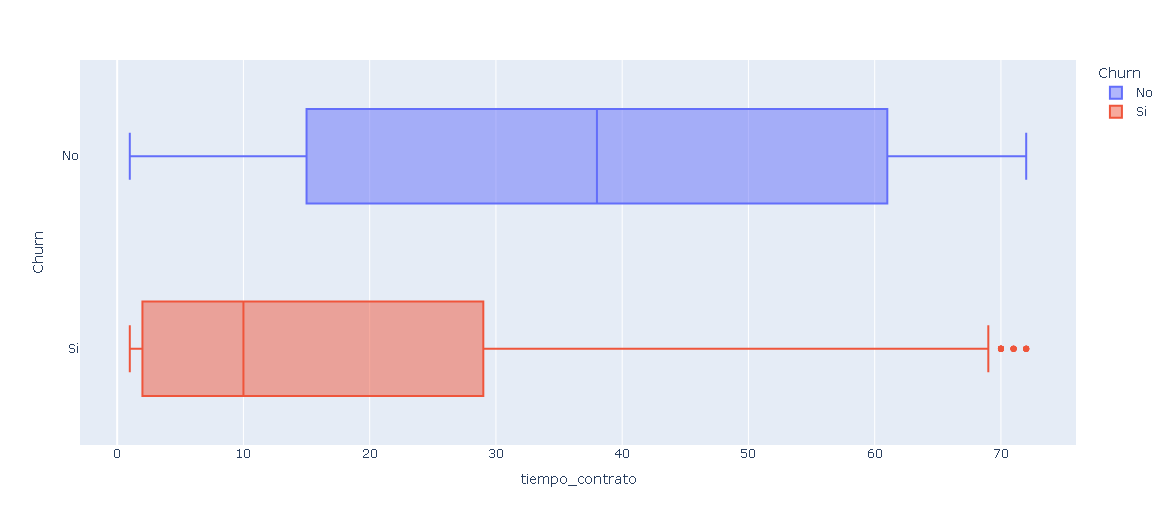

In [18]:
px.box(df, x = 'total_cobrado', y = 'Churn', color = 'Churn')

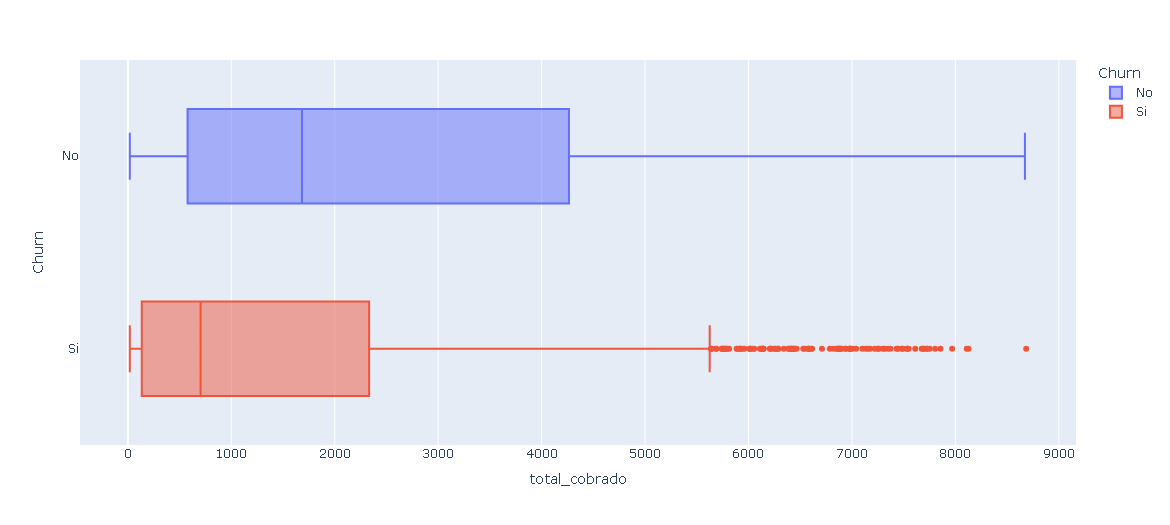

Observaciones

tiempo_contrato: los clientes que cancelan suelen tener un tiempo de contrato mucho más corto.

total_cobrado: los clientes no han acumulado mucha facturación histórica antes de irse.

## Análisis de correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

valores que se consideran en alto riesgo de multicolinealidad al efectuar correlaciones:

-Cuando es < 0.5: (baja correlación, normalmente no hay problema).

-Cuando es >= 0.5, < 0.7: (riesgo moderado, vigilar, posible multicolinealidad).

-Cuando es >= 0.7, < 0.9: (alta correlación, posible multicolinealidad).

-Cuando es >= 0.9: (muy alta correlación, muy alto riesgo de multicolinealidad).

-se empieza a revisar seriamente cuando es > a 0.8 -> aporta información redundante.

In [19]:
import matplotlib.pyplot as plt

In [20]:
import seaborn as sns

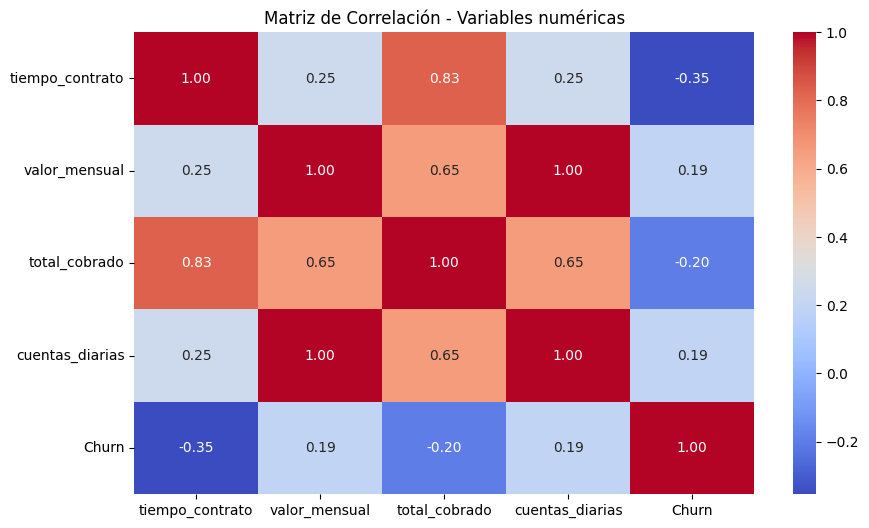

In [21]:
#Correlación entre variables numericas.

#Seleccionamos las varibles numéricas.

df_numeric = df.select_dtypes(include=["int64", "float64"])

#Convertir Churn a binario.

df_numeric["Churn"] = df["Churn"].map({"Si": 1, "No": 0})

#Calcular matriz de correlación.

corr_matrix = df_numeric.corr()

#Visualizar heatmap

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables numéricas")
plt.show()

In [22]:
corr_matrix['Churn']

,Churn
tiempo_contrato,-0.354049
valor_mensual,0.192858
total_cobrado,-0.199484
cuentas_diarias,0.192858
Churn,1.000000


In [23]:
corr_matrix['Churn'].sort_values(ascending=False).round(2)

,Churn
Churn,1.00
cuentas_diarias,0.19
valor_mensual,0.19
total_cobrado,-0.20
tiempo_contrato,-0.35


Observaciones

-La correlación entre tiempo_contrato y total_cobrado están muy cerca a 1, hay multicolinealidad, (hay que eliminar la columna total_cobrado). Hay que tener en cuenta, tiempo_contrato x valor_mensual = total_cobrado. No puedo obtener total_cobrado sin tiempo_contrato x valor_mensual. También hay que tener en cuenta que las correlaciones en total_cobrado están altas, a comparación de las correlaciones en tiempo_contrato son más bajas.

-La correlación entre valor_mensual y cuentas_diarias es la misma, son las mismas variables, hay que quitar una de ellas. (eliminamos la columna cuentas_diarias).

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   genero                  7032 non-null   object 
 2   tiene_mas_60            7032 non-null   object 
 3   posee_pareja            7032 non-null   object 
 4   posee_dependientes      7032 non-null   object 
 5   tiempo_contrato         7032 non-null   int64  
 6   servicio_telefono       7032 non-null   object 
 7   multiples_lineas        7032 non-null   object 
 8   tipo_internet           7032 non-null   object 
 9   seguridad_online        7032 non-null   object 
 10  backup_online           7032 non-null   object 
 11  proteccion_dispositivo  7032 non-null   object 
 12  soporte_tecnico         7032 non-null   object 
 13  streaming_tv            7032 non-null   object 
 14  streaming_peliculas     7032 non-null   

In [25]:
#Borramos las columnas que no son necesarias al analizar las correlaciones.

df = df.drop(columns=["total_cobrado","cuentas_diarias"])

In [26]:
df

,Churn,genero,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,No,Femenino,No,Si,Si,9,Si,No,DSL,No,Si,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60
1,No,Masculino,No,No,No,9,Si,Si,DSL,No,No,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90
2,Si,Masculino,No,No,No,4,Si,No,Fibra óptica,No,No,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90
3,Si,Masculino,Si,Si,No,13,Si,No,Fibra óptica,No,Si,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00
4,Si,Femenino,Si,Si,No,3,Si,No,Fibra óptica,No,No,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Femenino,No,No,No,13,Si,No,DSL,Si,No,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15
7028,Si,Masculino,No,Si,No,22,Si,Si,Fibra óptica,No,No,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10
7029,No,Masculino,No,No,No,2,Si,No,DSL,No,Si,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30
7030,No,Masculino,No,Si,Si,67,Si,No,DSL,Si,No,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   genero                  7032 non-null   object 
 2   tiene_mas_60            7032 non-null   object 
 3   posee_pareja            7032 non-null   object 
 4   posee_dependientes      7032 non-null   object 
 5   tiempo_contrato         7032 non-null   int64  
 6   servicio_telefono       7032 non-null   object 
 7   multiples_lineas        7032 non-null   object 
 8   tipo_internet           7032 non-null   object 
 9   seguridad_online        7032 non-null   object 
 10  backup_online           7032 non-null   object 
 11  proteccion_dispositivo  7032 non-null   object 
 12  soporte_tecnico         7032 non-null   object 
 13  streaming_tv            7032 non-null   object 
 14  streaming_peliculas     7032 non-null   

##Verificación de la proporción de cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados. Puedes usar value_counts() de pandas para obtener esta proporción.

In [28]:
#Calculamos la proporción (porcentaje).

#No cancelaron -> 73.4%

#Si cancelaron -> 26.6%

#Hay desbalanceamiento, pero es leve, esto podría influir en el desempeño de los modelos predictivos.

#Hablamos de un desbalanceamiento fuerte y brusco cuando es: 80% y 20% o 90% y 10%.

df['Churn'].value_counts(normalize=True).round(3)

,proportion
Churn,
No,0.734
Si,0.266


In [29]:
#Contamos cuántos registros hay de cada clase.

df['Churn'].value_counts()

,count
Churn,
No,5163
Si,1869


In [30]:
#Método que muestra cuáles son las variables no significativas.

#Método recomendado: Qui-cuadrado (Chi-Square Test).

#Efectuamos un registro completo.

#En estadística, para que una variable sea considerada "significativa", el p-valor suele ser menor a 0.05 (lo que indica que hay una relación real).

from sklearn.preprocessing import LabelEncoder #->Tranformamos nuestras variables categóricas en numéricas, solamente lo hacemos temporalmente en esta parte.
from sklearn.feature_selection import chi2

#Crear copia.

df_rank = df.copy()

#Convertir Churn para binario.

if df_rank["Churn"].dtype == 'object':
   df_rank["Churn"] = df_rank["Churn"].map({"Si": 1, "No": 0})

#Separar variables categóricas y aplicar Label Encoding temporario.

categorical_cols = df_rank.select_dtypes(include=["object"]).columns
le = LabelEncoder()

for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

#Aplicar test Qui-cuadrado.
X_cat = df_rank[categorical_cols]
y_rank = df_rank["Churn"]
chi_scores, p_values = chi2(X_cat, y_rank)

#Crear DataFrame con ranking.
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="p-value")

#Filtrado de variables no significativas (p-value > 0.05).
#Estas son las variables que fallan en rechazar la hipótesis nula (independientes de Churn).
significant_vars = chi_df[chi_df["p-value"] > 0.05]

print("Análisis de Independencia (Chi2):")
print(f"Variables analizadas: {len(categorical_cols)}")
print(f"Variables candidatas a ser eliminadas (p > 0.05): {len(significant_vars)}")
display(significant_vars)

#Quitamos las columnas que tienen menos asociación.

Análisis de Independencia (Chi2):
Variables analizadas: 16
Variables candidatas a ser eliminadas (p > 0.05): 3


,Variable,Chi2 Score,p-value
5,multiples_lineas,1.889982,0.169204
0,genero,0.254297,0.614066
4,servicio_telefono,0.092948,0.760462


In [31]:
#Eliminamos las columnas que no tienen similitud con Churn.

df = df.drop(columns=["genero", "servicio_telefono", "multiples_lineas"])

In [32]:
df

,Churn,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,No,No,Si,Si,9,DSL,No,Si,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60
1,No,No,No,No,9,DSL,No,No,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90
2,Si,No,No,No,4,Fibra óptica,No,No,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90
3,Si,Si,Si,No,13,Fibra óptica,No,Si,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00
4,Si,Si,Si,No,3,Fibra óptica,No,No,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,No,No,No,13,DSL,Si,No,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15
7028,Si,No,Si,No,22,Fibra óptica,No,No,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10
7029,No,No,No,No,2,DSL,No,Si,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30
7030,No,No,Si,Si,67,DSL,Si,No,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   tiene_mas_60            7032 non-null   object 
 2   posee_pareja            7032 non-null   object 
 3   posee_dependientes      7032 non-null   object 
 4   tiempo_contrato         7032 non-null   int64  
 5   tipo_internet           7032 non-null   object 
 6   seguridad_online        7032 non-null   object 
 7   backup_online           7032 non-null   object 
 8   proteccion_dispositivo  7032 non-null   object 
 9   soporte_tecnico         7032 non-null   object 
 10  streaming_tv            7032 non-null   object 
 11  streaming_peliculas     7032 non-null   object 
 12  tipo_contrato           7032 non-null   object 
 13  factura_digital         7032 non-null   object 
 14  metodo_pago             7032 non-null   

In [34]:
#Split

#Variables explicativas y variable de respuesta.

#Para realizar la predicción de los valores con un modelo de aprendizaje automático, necesitamos separar la variable objetivo de las variables explicativas. La variable y representa lo que queremos predecir, mientras que x incluye todas las variables que se utilizarán para explicar el comportamiento de y.

#Debemos separar el conjunto de datos en varible de respuesta y variables explicativas.

#churn -> Es la variable de respuesta.

#Las demás variables (el resto de columnas), son variables explicativas.

X = df.drop('Churn', axis = 1)
y = df['Churn']

In [35]:
#Pandas DataFrame.

X # X -> se trataría como de una matriz, al ver el DataFrame pensemos en una tabla que también es una matriz.

,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,No,Si,Si,9,DSL,No,Si,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60
1,No,No,No,9,DSL,No,No,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90
2,No,No,No,4,Fibra óptica,No,No,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90
3,Si,Si,No,13,Fibra óptica,No,Si,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00
4,Si,Si,No,3,Fibra óptica,No,No,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,No,No,13,DSL,Si,No,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15
7028,No,Si,No,22,Fibra óptica,No,No,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10
7029,No,No,No,2,DSL,No,Si,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30
7030,No,Si,Si,67,DSL,Si,No,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85


In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tiene_mas_60            7032 non-null   object 
 1   posee_pareja            7032 non-null   object 
 2   posee_dependientes      7032 non-null   object 
 3   tiempo_contrato         7032 non-null   int64  
 4   tipo_internet           7032 non-null   object 
 5   seguridad_online        7032 non-null   object 
 6   backup_online           7032 non-null   object 
 7   proteccion_dispositivo  7032 non-null   object 
 8   soporte_tecnico         7032 non-null   object 
 9   streaming_tv            7032 non-null   object 
 10  streaming_peliculas     7032 non-null   object 
 11  tipo_contrato           7032 non-null   object 
 12  factura_digital         7032 non-null   object 
 13  metodo_pago             7032 non-null   object 
 14  valor_mensual           7032 non-null   

In [37]:
#Pandas Series. -> serie de pandas.

y

,Churn
0,No
1,No
2,Si
3,Si
4,Si
...,...
7027,No
7028,Si
7029,No
7030,No


In [38]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7032 entries, 0 to 7031
Series name: Churn
Non-Null Count  Dtype 
--------------  ----- 
7032 non-null   object
dtypes: object(1)
memory usage: 55.1+ KB


##Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hotencoding.

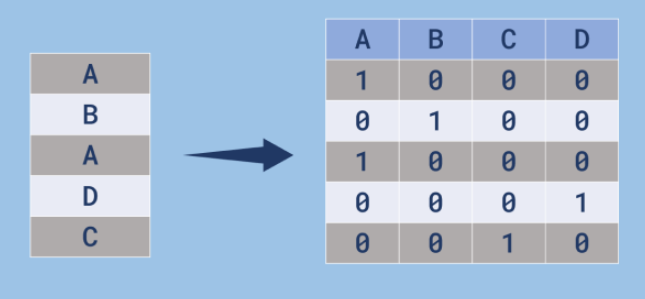

In [39]:
#Transformamos las variables explicativas.

#Los algoritmos de aprendizaje automático no comprenden datos en formato de texto, por lo que debemos transformar los datos a un formato numérico para que el algoritmo pueda interpretar la información. Esta transformación debe realizarse de manera que no altere la información original del conjunto de datos, por lo que no basta con simplemente cambiar los valores a números aleatorios.

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
columnas = X.columns

In [41]:
one_hot = make_column_transformer((OneHotEncoder(drop = 'if_binary'), # if_binary -> ignora las columnas que son binarias, porque no queremos que el módelo OneHotEncoder se aplique en todas las columnas, para que no se llene de ceros y unos innecesariamente.
                                  ['tiene_mas_60', 'posee_pareja', 'posee_dependientes', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago']),
                                  remainder = 'passthrough', #Lo que debe hacer con el resto de las columnas, que las omita, que las salte.
                                  sparse_threshold=0, #Nos permite determinar si queremos colocar una matriz sparce, osea llenar de ceros y algunos valores de uno, esto lo que va a hacer es simplificar de cierta manera el número, lo que va a hacer es quitar información relevante, lo ponemos en 0 como límite, de esta manera garantizamos que nuestro modelo no quite información relevante.
                                  force_int_remainder_cols=False) #force_int_remainder_cols -> Hace obligatorio que se cambie a entero el nombre de la columna, no queremos eso, queremos el nombre la columna como tal, lo dejamos en falso, en futuras versiones va a ser por defecto falso sin necesidad de ponerle el false, por el momento está en verdadero.

In [42]:
X = one_hot.fit_transform(X)

In [43]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__tiene_mas_60_Si', 'onehotencoder__posee_pareja_Si',
       'onehotencoder__posee_dependientes_Si',
       'onehotencoder__tipo_internet_DSL',
       'onehotencoder__tipo_internet_Fibra óptica',
       'onehotencoder__tipo_internet_No',
       'onehotencoder__seguridad_online_Si',
       'onehotencoder__backup_online_Si',
       'onehotencoder__proteccion_dispositivo_Si',
       'onehotencoder__soporte_tecnico_Si',
       'onehotencoder__streaming_tv_Si',
       'onehotencoder__streaming_peliculas_Si',
       'onehotencoder__tipo_contrato_Anual',
       'onehotencoder__tipo_contrato_Bienal',
       'onehotencoder__tipo_contrato_Mensual',
       'onehotencoder__factura_digital_Si',
       'onehotencoder__metodo_pago_Cheque electrónico',
       'onehotencoder__metodo_pago_Cheque enviado por correo',
       'onehotencoder__metodo_pago_Tarjeta de crédito (automático)',
       'onehotencoder__metodo_pago_Transferencia bancaria (automática)',
       'remainder__tiempo_c

In [44]:
#Cómo queda la variable explicativa, la matriz X.

X

array([[ 0.  ,  1.  ,  1.  , ...,  0.  ,  9.  , 65.6 ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  9.  , 59.9 ],
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  4.  , 73.9 ],
       ...,
       [ 0.  ,  0.  ,  0.  , ...,  0.  ,  2.  , 50.3 ],
       [ 0.  ,  1.  ,  1.  , ...,  0.  , 67.  , 67.85],
       [ 0.  ,  1.  ,  1.  , ...,  0.  , 63.  , 59.  ]])

Comparamos resultados

In [45]:
#Generemos un DataFrame para ver de manera más cercana en que consisten estos valores.

pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

,onehotencoder__tiene_mas_60_Si,onehotencoder__posee_pareja_Si,onehotencoder__posee_dependientes_Si,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fibra óptica,onehotencoder__tipo_internet_No,onehotencoder__seguridad_online_Si,onehotencoder__backup_online_Si,onehotencoder__proteccion_dispositivo_Si,onehotencoder__soporte_tecnico_Si,...,onehotencoder__tipo_contrato_Anual,onehotencoder__tipo_contrato_Bienal,onehotencoder__tipo_contrato_Mensual,onehotencoder__factura_digital_Si,onehotencoder__metodo_pago_Cheque electrónico,onehotencoder__metodo_pago_Cheque enviado por correo,onehotencoder__metodo_pago_Tarjeta de crédito (automático),onehotencoder__metodo_pago_Transferencia bancaria (automática),remainder__tiempo_contrato,remainder__valor_mensual
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,9.0,65.60
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.90
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,4.0,73.90
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,13.0,98.00
4,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,55.15
7028,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,22.0,85.10
7029,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,50.30
7030,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,67.0,67.85


In [46]:
df

,Churn,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,No,No,Si,Si,9,DSL,No,Si,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60
1,No,No,No,No,9,DSL,No,No,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90
2,Si,No,No,No,4,Fibra óptica,No,No,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90
3,Si,Si,Si,No,13,Fibra óptica,No,Si,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00
4,Si,Si,Si,No,3,Fibra óptica,No,No,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,No,No,No,13,DSL,Si,No,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15
7028,Si,No,Si,No,22,Fibra óptica,No,No,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10
7029,No,No,No,No,2,DSL,No,Si,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30
7030,No,No,Si,Si,67,DSL,Si,No,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85


In [47]:
#Transformamos la variable de respuesta.

#Así como las variables explicativas, la variable objetivo también debe convertirse al formato numérico. Podemos representar una variable objetivo binaria como 0 o 1, donde 0 indica la ausencia de la característica de la variable y 1 representa su presencia.

from sklearn.preprocessing import LabelEncoder

In [48]:
label_encoder = LabelEncoder()

In [49]:
y = label_encoder.fit_transform(y)

In [50]:
#Visualizamos y, para ver el array que nos muestra.

y

array([0, 0, 1, ..., 0, 0, 0])

In [51]:
#Observamos el DataFrame en y

pd.DataFrame(y, columns=['Churn'])

,Churn
0,0
1,0
2,1
3,1
4,1
...,...
7027,0
7028,1
7029,0
7030,0


##Verificación de la proporción de cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados. Puedes usar value_counts() de pandas para obtener esta proporción.

In [52]:
df_y = pd.DataFrame(y, columns=['Churn'])

In [53]:
#Calculamos la proporción (porcentaje).

#No cancelaron -> 73.4%

#Si cancelaron -> 26.6%

#pd.Series(y).value_counts(normalize=True).round(3)

df_y.value_counts(normalize=True).round(3)

,proportion
Churn,
0,0.734
1,0.266


In [54]:
#Contamos cuántos registros hay de cada clase.

#pd.Series(y).value_counts()

df_y.value_counts()

,count
Churn,
0,5163
1,1869


Observamos cómo están los datos

In [55]:
df_X = pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

In [56]:
df_X

,onehotencoder__tiene_mas_60_Si,onehotencoder__posee_pareja_Si,onehotencoder__posee_dependientes_Si,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fibra óptica,onehotencoder__tipo_internet_No,onehotencoder__seguridad_online_Si,onehotencoder__backup_online_Si,onehotencoder__proteccion_dispositivo_Si,onehotencoder__soporte_tecnico_Si,...,onehotencoder__tipo_contrato_Anual,onehotencoder__tipo_contrato_Bienal,onehotencoder__tipo_contrato_Mensual,onehotencoder__factura_digital_Si,onehotencoder__metodo_pago_Cheque electrónico,onehotencoder__metodo_pago_Cheque enviado por correo,onehotencoder__metodo_pago_Tarjeta de crédito (automático),onehotencoder__metodo_pago_Transferencia bancaria (automática),remainder__tiempo_contrato,remainder__valor_mensual
0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,9.0,65.60
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.90
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,4.0,73.90
3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,13.0,98.00
4,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13.0,55.15
7028,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,22.0,85.10
7029,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,50.30
7030,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,67.0,67.85


In [57]:
#pd.Series(y)

df_y

,Churn
0,0
1,0
2,1
3,1
4,1
...,...
7027,0
7028,1
7029,0
7030,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   tiene_mas_60            7032 non-null   object 
 2   posee_pareja            7032 non-null   object 
 3   posee_dependientes      7032 non-null   object 
 4   tiempo_contrato         7032 non-null   int64  
 5   tipo_internet           7032 non-null   object 
 6   seguridad_online        7032 non-null   object 
 7   backup_online           7032 non-null   object 
 8   proteccion_dispositivo  7032 non-null   object 
 9   soporte_tecnico         7032 non-null   object 
 10  streaming_tv            7032 non-null   object 
 11  streaming_peliculas     7032 non-null   object 
 12  tipo_contrato           7032 non-null   object 
 13  factura_digital         7032 non-null   object 
 14  metodo_pago             7032 non-null   

In [59]:
#pd.Series(y).info()

df_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Churn   7032 non-null   int64
dtypes: int64(1)
memory usage: 55.1 KB


In [60]:
df_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   onehotencoder__tiene_mas_60_Si                                  7032 non-null   float64
 1   onehotencoder__posee_pareja_Si                                  7032 non-null   float64
 2   onehotencoder__posee_dependientes_Si                            7032 non-null   float64
 3   onehotencoder__tipo_internet_DSL                                7032 non-null   float64
 4   onehotencoder__tipo_internet_Fibra óptica                       7032 non-null   float64
 5   onehotencoder__tipo_internet_No                                 7032 non-null   float64
 6   onehotencoder__seguridad_online_Si                              7032 non-null   float64
 7   onehotencoder__backup_online_Si                    

## Análisis de correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

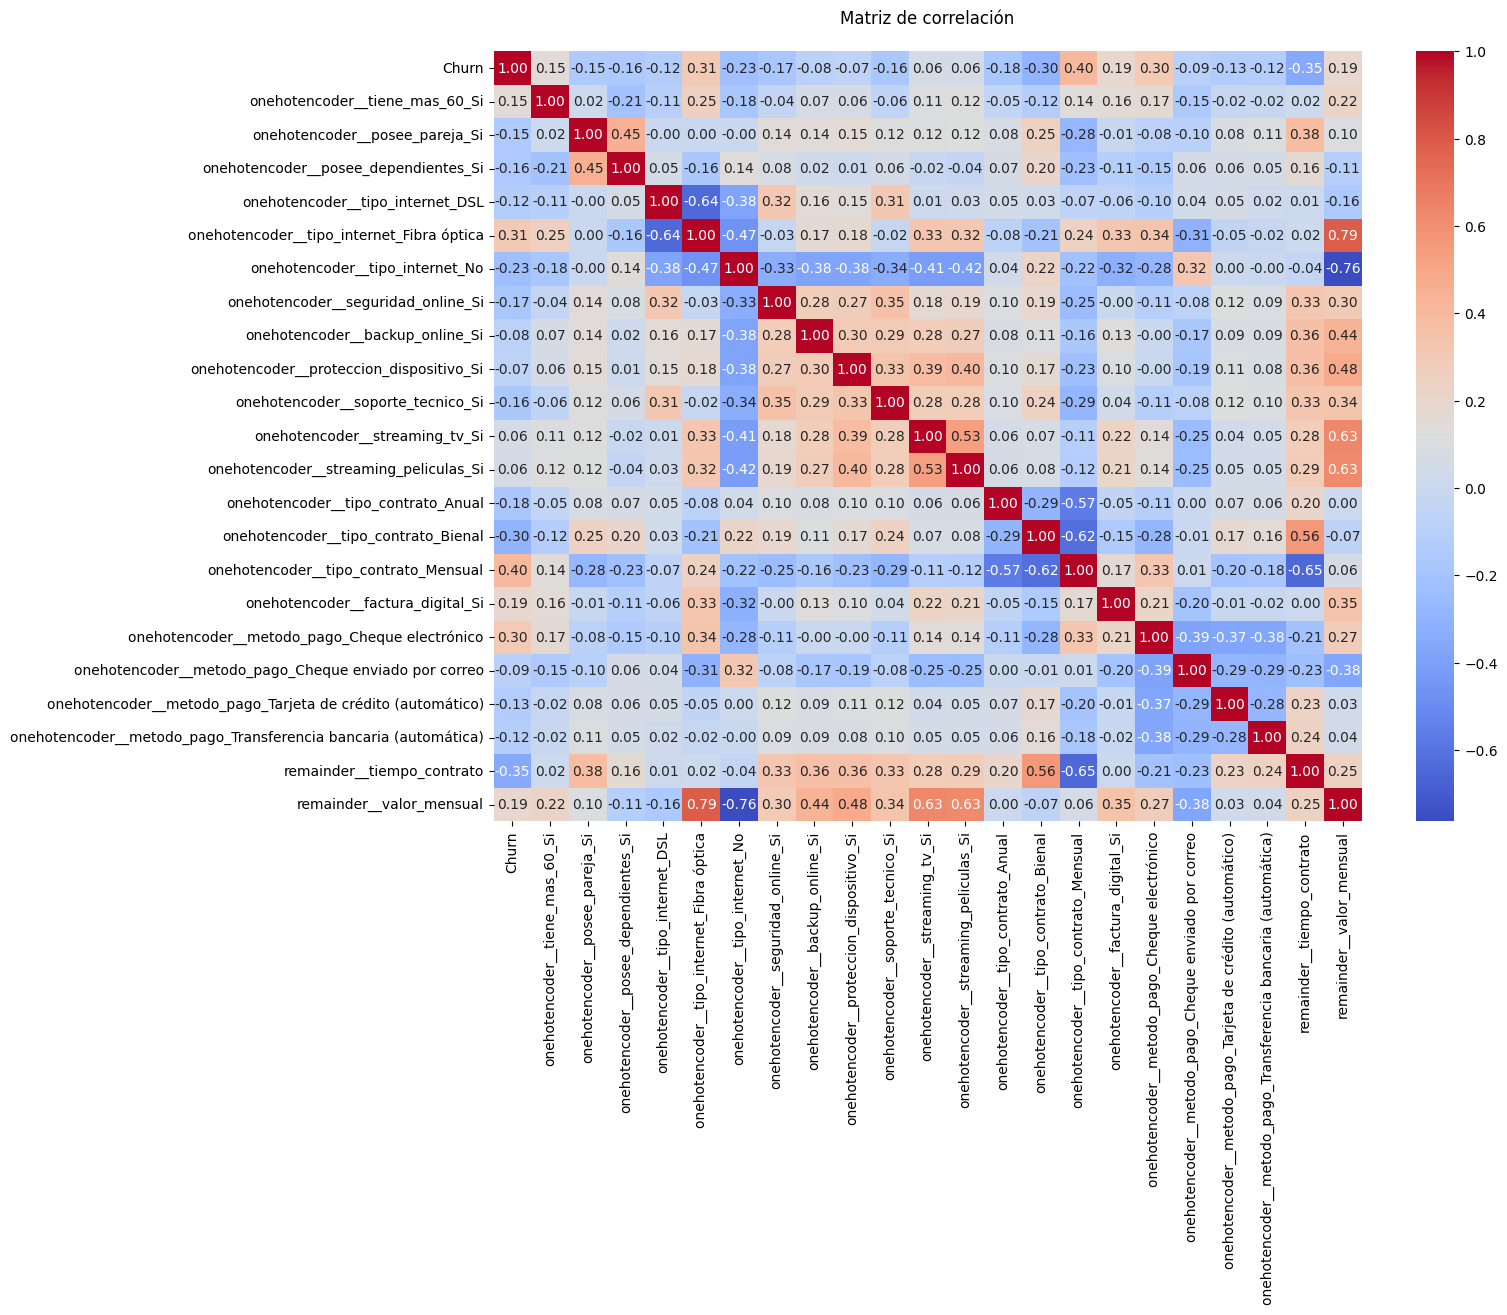

In [61]:
#Incluir df_y y df_X.

df_combinado = pd.concat([df_y, df_X], axis=1)

#Calcular matriz de correlación.

corre_matrix = df_combinado.corr()

#Visualizar heatmap.

plt.figure(figsize=(14,10))
sns.heatmap(corre_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación", pad=20)
plt.show()

In [62]:
#Mostrar correlaciones con Churn.

pd.concat([df_X, df_y], axis=1).corr()['Churn'].sort_values(ascending=False).round(2)

,Churn
Churn,1.00
onehotencoder__tipo_contrato_Mensual,0.40
onehotencoder__tipo_internet_Fibra óptica,0.31
onehotencoder__metodo_pago_Cheque electrónico,0.30
remainder__valor_mensual,0.19
onehotencoder__factura_digital_Si,0.19
onehotencoder__tiene_mas_60_Si,0.15
onehotencoder__streaming_tv_Si,0.06
onehotencoder__streaming_peliculas_Si,0.06
onehotencoder__proteccion_dispositivo_Si,-0.07


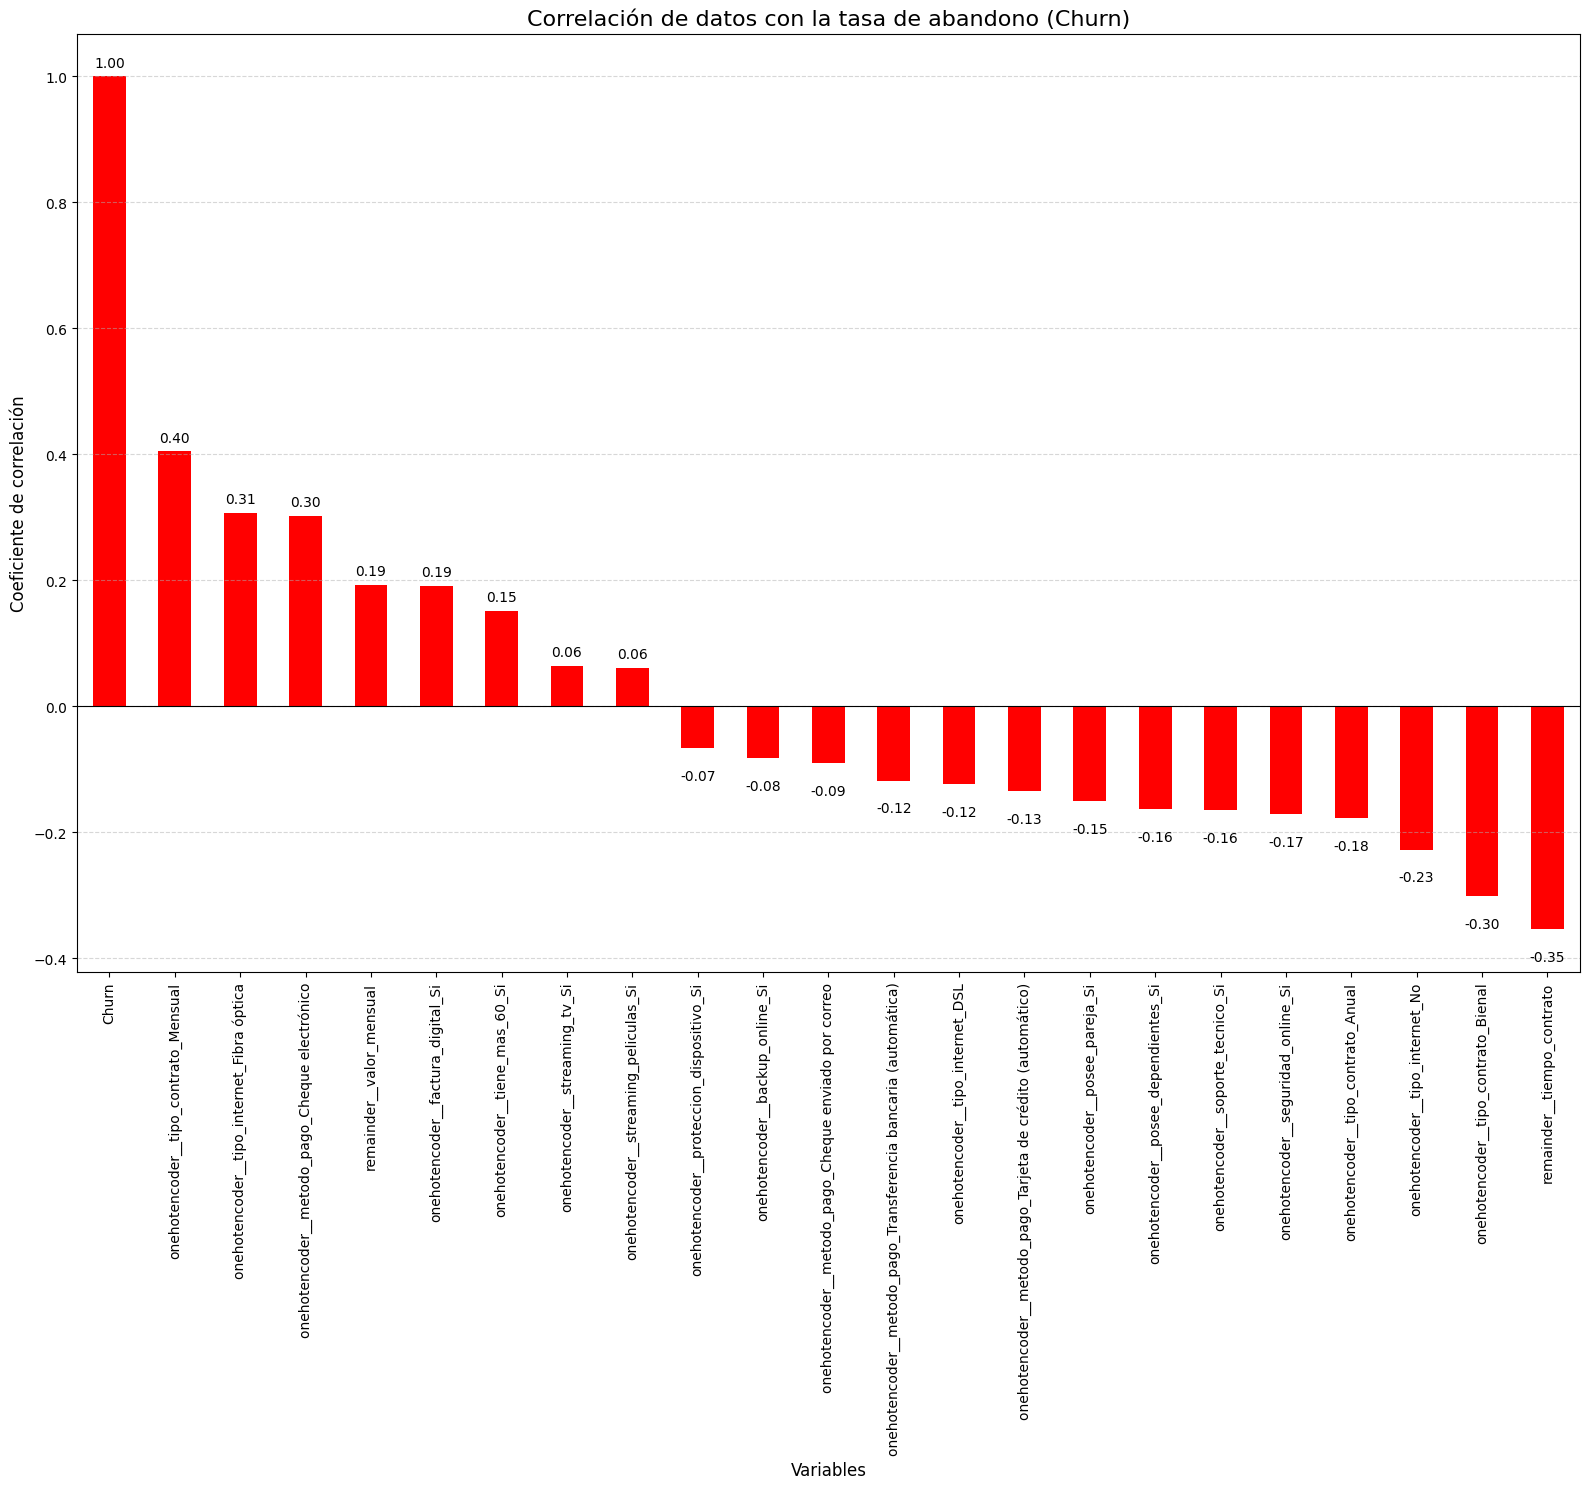

In [63]:
df_corr_processed = pd.concat([df_X, df_y], axis=1)

#Cálculo de correlaciones.

correlaciones = df_corr_processed.corr()['Churn'].sort_values(ascending=False)

#Creación del gráfico.

plt.figure(figsize=(16,15))

ax = correlaciones.plot(kind='bar', color='red')

#Añadir los valores dinámicamente.
for p in ax.patches:
    height = p.get_height()

    va_position = 'bottom' if height > 0 else 'top'
    offset = 5 if height > 0 else -15

    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width()/2., height),
                ha='center',
                va=va_position,
                xytext=(0, offset),
                textcoords='offset points',
                fontsize=10)

#Estética final.

plt.title('Correlación de datos con la tasa de abandono (Churn)', fontsize=16)
plt.ylabel('Coeficiente de correlación', fontsize=12)
plt.xlabel('Variables', fontsize=12)

plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Ajustando modelos

## Separación de datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 75/25, 80/20, dependiendo del tamaño de la base de datos

## Dividiendo los datos entre entrenamiento y prueba

Para comprender si el modelo realmente está aprendiendo de los datos, necesitamos hacer una separación de los datos entre entrenamiento y prueba. Los datos de **entrenamiento** se utilizan para ajustar el modelo, mientras que los datos de **prueba** sirven para verificar el aprendizaje del modelo en datos que no fueron utilizados en el momento del ajuste.

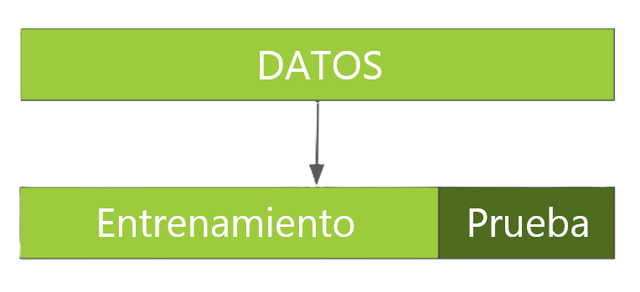

In [64]:
#Dividiendo los datos entre entrenamiento y prueba.

from sklearn.model_selection import train_test_split

In [65]:
#Para comprender si el modelo realmente está aprendiendo de los datos, necesitamos hacer una separación de los datos entre entrenamiento y prueba. Los datos de entrenamiento se utilizan para ajustar el modelo, mientras que los datos de prueba sirven para verificar el aprendizaje del modelo en datos que no fueron utilizados en el momento del ajuste.

#Dejamos para entrenamiento el 75%.

#Dejamos para prueba el 25%.

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y,  random_state = 5) #stratify = y -> Se usa para que train y test estén balanceados, haya un balanceo de datos.

#stratify -> Nos permite estratificar nuestra base de modo que la cantidad de observaciones sea similar tanto en la base de prueba como en la base de entrenamiento de la variable de respuesta. Es decir, si en el 75% de nuestras muestras para entrenar tenemos un 30% de observaciones negativas y un 70% positivas, deseamos que en el 25% de nuestra base de prueba también haya un 30% de observaciones negativas y un 70% positivas. Especificamos el array que deseamos dejar, por lo tanto, stratify igual a y, que sería el array de la salida. De esta manera, garantizamos que tanto en la base de entrenamiento como en la base de prueba tengamos la misma proporción de observaciones, tanto de si como de no. La misma proporción de salida de 1 y de 0 en ambos casos.

#random_state -> Lo dejamos en 5, aunque se puede colocar el número que se desee.

In [66]:
#pd.DataFrame(X_train).head()

pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,71.0,65.15
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,70.0,90.25
2,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,58.0,109.45
3,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,60.0,59.85
4,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,29.0,94.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5269,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,45.0,81.40
5270,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,42.0,55.65
5271,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,45.0,20.00
5272,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,29.0,66.10


In [67]:
pd.DataFrame(X_train).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5274 entries, 0 to 5273
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       5274 non-null   float64
 1   1       5274 non-null   float64
 2   2       5274 non-null   float64
 3   3       5274 non-null   float64
 4   4       5274 non-null   float64
 5   5       5274 non-null   float64
 6   6       5274 non-null   float64
 7   7       5274 non-null   float64
 8   8       5274 non-null   float64
 9   9       5274 non-null   float64
 10  10      5274 non-null   float64
 11  11      5274 non-null   float64
 12  12      5274 non-null   float64
 13  13      5274 non-null   float64
 14  14      5274 non-null   float64
 15  15      5274 non-null   float64
 16  16      5274 non-null   float64
 17  17      5274 non-null   float64
 18  18      5274 non-null   float64
 19  19      5274 non-null   float64
 20  20      5274 non-null   float64
 21  21      5274 non-null   float64
dtype

In [68]:
pd.DataFrame(X_test)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,28.0,19.90
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,50.0,69.75
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,59.0,95.80
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,14.0,80.90
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,18.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,66.0,107.35
1754,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,6.0,91.00
1755,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,66.0,66.10
1756,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,22.0,20.15


In [69]:
pd.DataFrame(X_test).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1758 non-null   float64
 1   1       1758 non-null   float64
 2   2       1758 non-null   float64
 3   3       1758 non-null   float64
 4   4       1758 non-null   float64
 5   5       1758 non-null   float64
 6   6       1758 non-null   float64
 7   7       1758 non-null   float64
 8   8       1758 non-null   float64
 9   9       1758 non-null   float64
 10  10      1758 non-null   float64
 11  11      1758 non-null   float64
 12  12      1758 non-null   float64
 13  13      1758 non-null   float64
 14  14      1758 non-null   float64
 15  15      1758 non-null   float64
 16  16      1758 non-null   float64
 17  17      1758 non-null   float64
 18  18      1758 non-null   float64
 19  19      1758 non-null   float64
 20  20      1758 non-null   float64
 21  21      1758 non-null   float64
dtype

In [70]:
pd.DataFrame(y_train)

,0
0,0
1,0
2,1
3,0
4,1
...,...
5269,0
5270,0
5271,0
5272,0


In [71]:
pd.DataFrame(y_train).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5274 entries, 0 to 5273
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       5274 non-null   int64
dtypes: int64(1)
memory usage: 41.3 KB


In [72]:
pd.DataFrame(y_test)

,0
0,0
1,0
2,0
3,0
4,0
...,...
1753,0
1754,1
1755,0
1756,0


In [73]:
pd.DataFrame(y_test).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1758 non-null   int64
dtypes: int64(1)
memory usage: 13.9 KB


## Verificación de la proporción de cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados. Puedes usar value_counts() de pandas para obtener esta proporción.

In [74]:
#Calculamos la proporción (porcentaje).

#No cancelaron -> 73.4%

#Si cancelaron -> 26.6%

#Hay desbalanceamiento, pero es leve, no extremo, esto podría influir en el desempeño de los modelos predictivos.

#Hablamos de un desbalanceamiento fuerte y brusco cuando es: 80% y 20%, 85% y 15% o 90% y 10%.

pd.Series(y_train).value_counts(normalize=True).round(3) * 100

,proportion
0,73.4
1,26.6


## Creación de modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

## Evaluación de los modelos

Evalúa cada modelo utilizando las siguientes métricas:

-Exactitud (Acurácia).

-Precisión.

-Recall.

-F1-score.

-Matriz de confusión.


In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

In [76]:
from sklearn.metrics import classification_report #classification_report -> Nos muestra precision, recall, f1-score, support, etc...

## Modelo árboles de decisión

In [77]:
from sklearn.tree import DecisionTreeClassifier

              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1291
           1       0.67      0.40      0.50       467

    accuracy                           0.79      1758
   macro avg       0.74      0.66      0.68      1758
weighted avg       0.77      0.79      0.77      1758



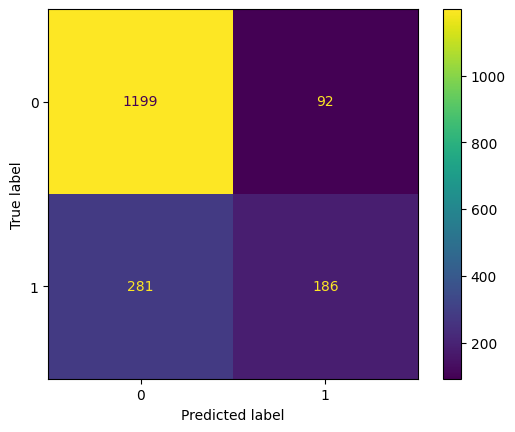

In [78]:
arbol = DecisionTreeClassifier(max_depth = 3, random_state = 5)
arbol.fit(X_train, y_train)
y_previsto_arbol = arbol.predict(X_test)

print(classification_report(y_test, y_previsto_arbol))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto_arbol);

In [79]:
from sklearn.metrics import RocCurveDisplay

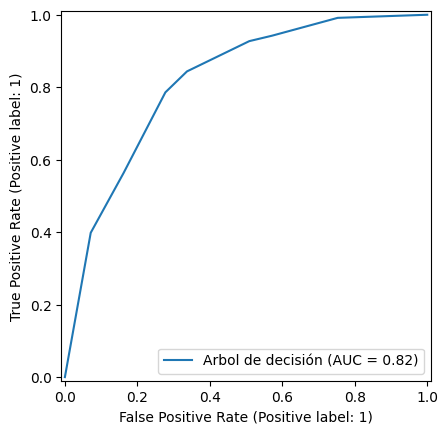

In [80]:
y_previsto_arbol_roc = arbol.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_previsto_arbol_roc, name='Arbol de decisión');

## Modelo Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1291
           1       0.60      0.49      0.54       467

    accuracy                           0.78      1758
   macro avg       0.71      0.69      0.70      1758
weighted avg       0.77      0.78      0.77      1758



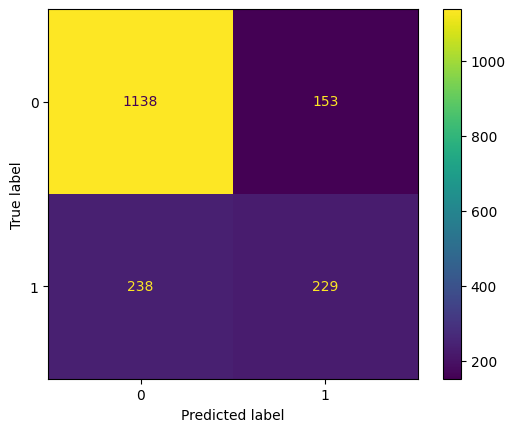

In [82]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_previsto_rf = rf.predict(X_test)

print(classification_report(y_test, y_previsto_rf))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto_rf);

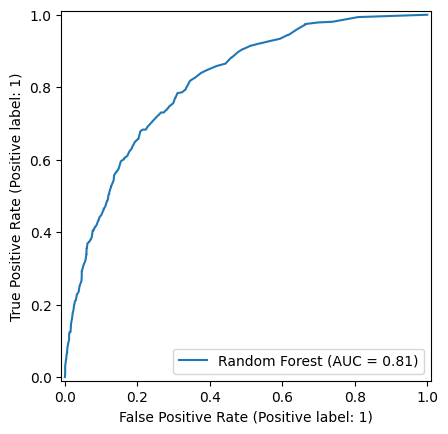

In [83]:
y_previsto_rf_roc = rf.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_previsto_rf_roc, name='Random Forest');

## Modelo XGBoost

In [84]:
from xgboost import XGBClassifier

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1291
           1       0.58      0.52      0.55       467

    accuracy                           0.77      1758
   macro avg       0.71      0.69      0.70      1758
weighted avg       0.77      0.77      0.77      1758



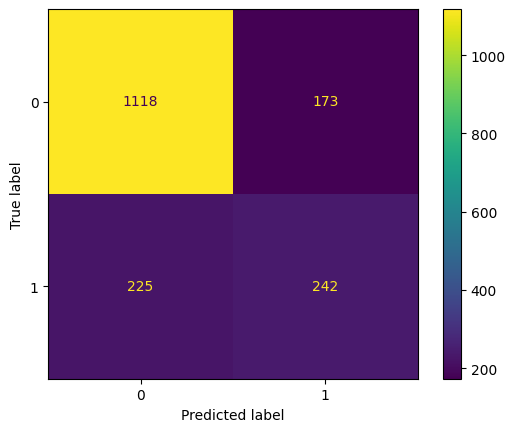

In [85]:
xgb = XGBClassifier(random_state=5, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_previsto_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_previsto_xgb))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto_xgb);

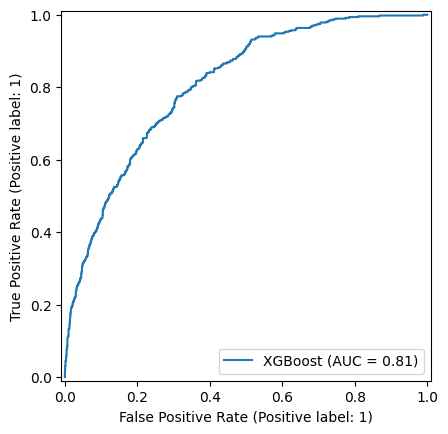

In [86]:
y_previsto_xgb_roc = xgb.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_previsto_xgb_roc, name='XGBoost');

## Modelo regresión logística

In [87]:
from sklearn.linear_model import LogisticRegression

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1291
           1       0.67      0.55      0.61       467

    accuracy                           0.81      1758
   macro avg       0.76      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758



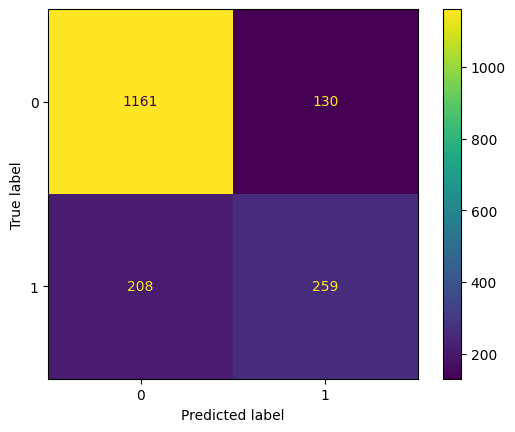

In [88]:
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)
y_previsto_log_normal = log.predict(X_test)

print(classification_report(y_test, y_previsto_log_normal))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto_log_normal);

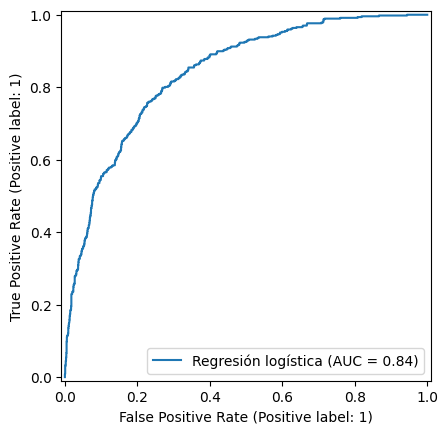

In [89]:
y_previsto_log_roc = log.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_previsto_log_roc, name='Regresión logística');

## Modelo KNN

In [90]:
from sklearn.neighbors import KNeighborsClassifier

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1291
           1       0.57      0.51      0.54       467

    accuracy                           0.77      1758
   macro avg       0.70      0.68      0.69      1758
weighted avg       0.76      0.77      0.76      1758



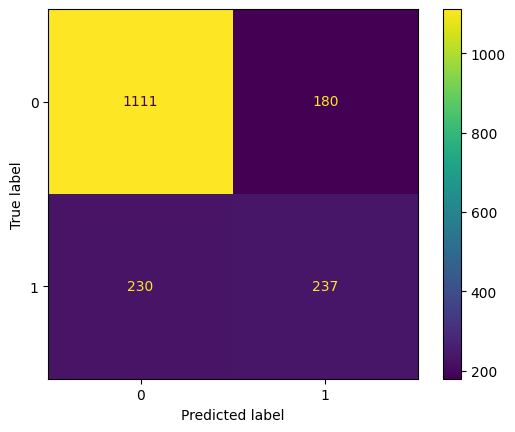

In [91]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_previsto_knn = knn.predict(X_test)

print(classification_report(y_test, y_previsto_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto_knn);

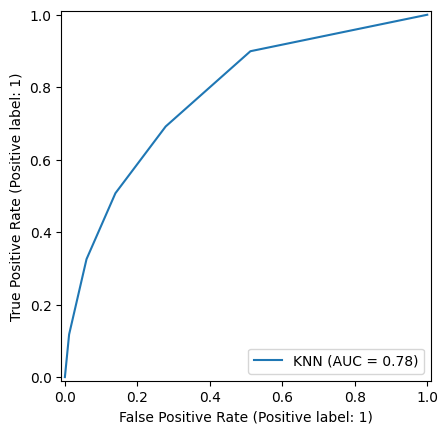

In [92]:
y_previsto_knn_roc = knn.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_previsto_knn_roc, name='KNN');

## Escogiendo y serializando el mejor modelo

Al final de un proyecto de machine learning, debemos comparar los resultados de los modelos y elegir el que tenga el mejor rendimiento.

In [93]:
print(f'Exactitud modelo árbol de decisión: {arbol.score(X_test, y_test):.2f}')
print(f'Exactitud modelo Random forest: {rf.score(X_test, y_test):.2f}')
print(f'Exactitud modelo XGBoost: {xgb.score(X_test, y_test):.2f}')
print(f'Exactitud modelo regresión logística: {log.score(X_test, y_test):.2f}')
print(f'Exactitud modelo KNN: {knn.score(X_test, y_test):.2f}') #Observamos que al quitar las columnas genero, servicio_telefono, multiples_lineas, total_cobrado y cuentas_diarias, El modelo KNN se acercó más al 100%.

Exactitud modelo árbol de decisión: 0.79
Exactitud modelo Random forest: 0.78
Exactitud modelo XGBoost: 0.77
Exactitud modelo regresión logística: 0.81
Exactitud modelo KNN: 0.77


In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

modelos = {
    "Árbol de decisión": (y_previsto_arbol, y_previsto_arbol_roc),
    "Random forest": (y_previsto_rf, y_previsto_rf_roc),
    "XGBoost": (y_previsto_xgb, y_previsto_xgb_roc),
    "Regresión logística": (y_previsto_log_normal, y_previsto_log_roc),
    "KNN": (y_previsto_knn, y_previsto_knn_roc)
}

resultados = []

for nombre, (y_pred, y_prob) in modelos.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(by="F1-score", ascending=False)

df_resultados = df_resultados.reset_index(drop=True)

df_resultados.round(2)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Regresión logística,0.81,0.67,0.55,0.61,0.84
1,XGBoost,0.77,0.58,0.52,0.55,0.81
2,Random forest,0.78,0.60,0.49,0.54,0.81
3,KNN,0.77,0.57,0.51,0.54,0.78
4,Árbol de decisión,0.79,0.67,0.40,0.50,0.82


Podemos almacenar el modelo en un archivo serializado del tipo pickle para que sea utilizado en producción, es decir, en datos del mundo real para atender las necesidades del problema que necesita ser resuelto.

In [95]:
import pickle #pickle -> Nos permite crear archivos binarios. este archivo binario contendrá nuestro modelo de Machine Learning serializado, listo para consumo.

In [96]:
with open('modelo_onehotencoder.pkl', 'wb') as archivo:
    pickle.dump(one_hot, archivo)

In [97]:
with open('modelo_champion.pkl', 'wb') as archivo:
    pickle.dump(log, archivo)

In [98]:
df

,Churn,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,No,No,Si,Si,9,DSL,No,Si,No,Si,Si,No,Anual,Si,Cheque enviado por correo,65.60
1,No,No,No,No,9,DSL,No,No,No,No,No,Si,Mensual,No,Cheque enviado por correo,59.90
2,Si,No,No,No,4,Fibra óptica,No,No,Si,No,No,No,Mensual,Si,Cheque electrónico,73.90
3,Si,Si,Si,No,13,Fibra óptica,No,Si,Si,No,Si,Si,Mensual,Si,Cheque electrónico,98.00
4,Si,Si,Si,No,3,Fibra óptica,No,No,No,Si,Si,No,Mensual,Si,Cheque enviado por correo,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,No,No,No,13,DSL,Si,No,No,Si,No,No,Anual,No,Cheque enviado por correo,55.15
7028,Si,No,Si,No,22,Fibra óptica,No,No,No,No,No,Si,Mensual,Si,Cheque electrónico,85.10
7029,No,No,No,No,2,DSL,No,Si,No,No,No,No,Mensual,Si,Cheque enviado por correo,50.30
7030,No,No,Si,Si,67,DSL,Si,No,Si,Si,No,Si,Bienal,No,Cheque enviado por correo,67.85


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Churn                   7032 non-null   object 
 1   tiene_mas_60            7032 non-null   object 
 2   posee_pareja            7032 non-null   object 
 3   posee_dependientes      7032 non-null   object 
 4   tiempo_contrato         7032 non-null   int64  
 5   tipo_internet           7032 non-null   object 
 6   seguridad_online        7032 non-null   object 
 7   backup_online           7032 non-null   object 
 8   proteccion_dispositivo  7032 non-null   object 
 9   soporte_tecnico         7032 non-null   object 
 10  streaming_tv            7032 non-null   object 
 11  streaming_peliculas     7032 non-null   object 
 12  tipo_contrato           7032 non-null   object 
 13  factura_digital         7032 non-null   object 
 14  metodo_pago             7032 non-null   

In [100]:
nuevo_dato = {
    'tiene_mas_60':['No'],
    'posee_pareja':['No'],
    'posee_dependientes': ['No'],
    'tiempo_contrato': [4],
    'tipo_internet': ['Fibra óptica'],
    'seguridad_online': ['Si'],
    'backup_online': ['Si'],
    'proteccion_dispositivo': ['Si'],
    'soporte_tecnico': ['Si'],
    'streaming_tv': ['Si'],
    'streaming_peliculas': ['Si'],
    'tipo_contrato': ['Mensual'],
    'factura_digital': ['Si'],
    'metodo_pago': ['Cheque electrónico'],
    'valor_mensual': [98.00],
}

In [101]:
nuevo_dato = pd.DataFrame(nuevo_dato)
nuevo_dato

,tiene_mas_60,posee_pareja,posee_dependientes,tiempo_contrato,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensual
0,No,No,No,4,Fibra óptica,Si,Si,Si,Si,Si,Si,Mensual,Si,Cheque electrónico,98.0


In [102]:
modelo_one_hot = pd.read_pickle('/content/modelo_onehotencoder.pkl')
log = pd.read_pickle('/content/modelo_champion.pkl')

In [103]:
nuevo_dato = modelo_one_hot.transform(nuevo_dato)
log.predict(nuevo_dato)

array([1])

#📄 Informe final

Para la empresa de telecomunicaciones TelecomX, el modelo recomendado es regresión logística porque ofrece los mejores resultados, priorizando el recall, el F1-score y el ROC como exactitudes globales para identificar los clientes que van a cancelar el servicio.

Este tipo de análisis permite a las empresas tomar decisiones basadas en datos y diseñar estrategias de retención más efectivas, reduciendo la pérdida de clientes y mejorar la estabilidad del negocio.